In [1]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from tqdm import tqdm
from numba import njit
from numba import set_num_threads
#set_num_threads(1)
import pandas as pd
import os
from concurrent.futures import ProcessPoolExecutor
import time

#### Initial Ordered State and Noise Model

In [2]:
#Initialize state. 
@njit
def init_ordered(L):
    return np.ones((3,L,L,L), dtype = np.int64)
@njit
def apply_noise(initial, p):
    out = initial.copy()
    L = len(initial[0][0][0])
    for d in range(3):
        for i in range(initial.shape[1]):
            for j in range(initial.shape[2]):
                for k in range(initial.shape[3]):
                    if np.random.rand() < p:
                        out[d,i, j, k] *=-1
    return out

#Spanning Membranes for Generating Wilson Loop Sectors
@njit
def Spanning_Membrane_Wx(state,x): #flips sign of W_x
    out = state.copy()
    L = state.shape[1]
    for j in range(L):
        for k in range(L):
            out[0,x,j,k] *= -1
    return out
@njit
def Spanning_Membrane_Wy(state,y): #flips sign of W_y
    out = state.copy()
    L = state.shape[1]
    for i in range(L):
        for k in range(L):
            out[1,i,y,k] *= -1
    return out
@njit
def Spanning_Membrane_Wz(state,z): #flips sign of W_z
    out = state.copy()
    L = state.shape[1]
    for i in range(L):
        for j in range(L):
            out[2,i,j,z] *= -1
    return out

#### Plaquettes

In [3]:
@njit
def Pxy(i,j,k,sigma):
    L = sigma.shape[1] #lattice side length
    #accounting for periodic boundary conditions
    return sigma[0,i,j,k]*sigma[1,(i+1)%L,j,k]*sigma[0,i,(j+1)%L,k]*sigma[1,i,j,k]
@njit
def Pxz(i,j,k,sigma):
    L = sigma.shape[1]
    return sigma[0,i,j,k]*sigma[2,(i+1)%L,j,k]*sigma[0,i,j,(k+1)%L]*sigma[2,i,j,k]
@njit
def Pyz(i,j,k,sigma):
    L = sigma.shape[1]
    return sigma[1,i,j,k]*sigma[2,i,(j+1)%L,k]*sigma[1,i,j,(k+1)%L]*sigma[2,i,j,k]


#### Lattice in terms of plaquette

In [4]:
def Plattice(sigma):
    #calculates all the plaquettes in the lattice and returns a 3*3 array
    L = sigma.shape[1]
    init = np.ones((3,L,L,L), dtype = np.int64)
    for i in range(L):
        for j in range(L):
            for k in range(L):
                init[0,i,j,k] = Pxy(i,j,k,sigma)
                init[1,i,j,k] = Pyz(i,j,k,sigma)
                init[2,i,j,k] = Pxz(i,j,k,sigma)
    return init

#### Frustrated Plaquette Density Function

In [5]:
#FRUSTRATED PLAQUETTE DENSITY FUNCTION 
@njit
def FPdensity(sigma):
    #calculates the density of frustrated plaquettes in a given configuration 
    tot = 0
    frs = 0
    L = sigma.shape[1]
    for i in range(L):
        for j in range(L):
            for k in range(L): #three plaquettes associated with each edge
                P1 = Pxy(i,j,k,sigma)
                P2 = Pxz(i,j,k,sigma)
                P3 = Pyz(i,j,k,sigma)
                tot += 3 #total plaquette count
                if P1 == -1:
                    frs += 1
                if P2 == -1:
                    frs +=1
                if P3 == -1:
                    frs += 1
    return frs/tot

#### Local Change in Energy

In [6]:
@njit
def delta_E_edge(i,j,k,mu,sigma):
    L = sigma.shape[1]
    if mu == 0: #x edge
        dE = 2*(Pxz(i,j,k,sigma) + Pxy(i,j,k,sigma) + Pxz(i,j,(k-1)%L,sigma) + Pxy(i,(j-1)%L,k,sigma))
    if mu == 1: #y edge
        dE = 2*(Pxy(i,j,k,sigma) + Pyz(i,j,k,sigma) + Pxy((i-1)%L,j,k,sigma) + Pyz(i,j,(k-1)%L,sigma))
    if mu == 2: #z edge
        dE = 2*(Pyz(i,j,k,sigma) + Pxz(i,j,k,sigma) + Pyz(i,(j-1)%L,k,sigma) + Pxz((i-1)%L,j,k,sigma))
    return dE

### Zero Temperature Glauber

In [7]:
#Glauber Updates Version with completely random site selection
@njit
def Glauber_sweep(sigma): 
        L = sigma.shape[1]
        state = sigma.copy()
        for _ in range(3*L*L*L): #this is the number of edges, not vertices, for the number of spins
            i = np.random.randint(0,L)
            j = np.random.randint(0,L)
            k = np.random.randint(0,L)
            mu = np.random.randint(0,3) #randomly select edge type
            DE = delta_E_edge(i,j,k,mu,state)
            if DE < 0:
                state[mu,i,j,k] *= -1
            elif DE ==  0:
                if np.random.rand() < 0.5:
                        state[mu,i,j,k] *= -1
        return state

#### Wilson Loops

In [8]:
@njit
def W_x(sigma):
    L = sigma.shape[1]
    sign_Wx = 1
    Wx = np.ones((L,L), dtype=np.int64)
    for y in range(L):
        for z in range(L):
            w = 1
            for x in range(L):
                w *= sigma[0,x,y,z]
            Wx[y,z] = w
    sign_Wx = np.sum(Wx)/len(Wx)**2
    return Wx, sign_Wx
@njit
def W_y(sigma):
    L = sigma.shape[1]
    sign_Wy = 1
    Wy = np.ones((L,L), dtype=np.int64)
    for x in range(L):
        for z in range(L):
            w = 1
            for y in range(L):
                w *= sigma[1,x,y,z]
            Wy[x,z] = w
    sign_Wy = np.sum(Wy)/len(Wy)**2
    return Wy, sign_Wy
@njit
def W_z(sigma):
    L = sigma.shape[1]
    sign_Wz = 1
    Wz = np.ones((L,L), dtype=np.int64)
    for x in range(L):
        for y in range(L):
            w = 1
            for z in range(L):
                w *= sigma[2,x,y,z]
            Wz[x,y] = w
    sign_Wz = np.sum(Wz)/len(Wz)**2
    return Wz, sign_Wz

#### Decoding Loop

In [9]:
@njit
def run_single_trial(args):
    L, pnoise, W_arr, seed = args
    max_sweeps = int(L*L*L/2) #Reconsider
    threshold = L*L #5*L*L
    f = 0 #logical failure tracker
    c = 0 #convergence failure tracker
    np.random.seed(seed)

    psi_i = init_ordered(L)

    #establishing logical sector
    if W_arr[0] == -1:
        psi_i = Spanning_Membrane_Wx(psi_i,x = L//2) # alternatively: x = np.random.randint(0, L)
    if W_arr[1] == -1:
        psi_i = Spanning_Membrane_Wy(psi_i,y = L//2)
    if W_arr[2] == -1:
        psi_i = Spanning_Membrane_Wz(psi_i,z = L//2)
        
    psi_i = apply_noise(psi_i,pnoise)
    psi_G = psi_i.copy()

    #setup for timescale measurements
    rho0 = FPdensity(psi_G)
    HalfFlux = 0.5*rho0
    tau = max_sweeps #in case no half point is achieved
    tau_recorded = False
    
    flux = rho0
    t = 0
    last_flux = flux
    unchanged_counter = 0
    
    while flux != 0 and t < max_sweeps:
        
        psi_G = Glauber_sweep(psi_G)
        t += 1
        flux = FPdensity(psi_G)

        if flux <= HalfFlux and not tau_recorded:
            tau = t
            tau_recorded = True #to not update tau again 

        if flux == last_flux:
            unchanged_counter += 1
            if unchanged_counter > threshold:
                break
        else:
            last_flux = flux
            unchanged_counter = 0
            
    Wf_arr = np.array([W_x(psi_G)[1], W_y(psi_G)[1], W_z(psi_G)[1]])

    if not np.array_equal(W_arr, Wf_arr): #logical failure
        f = 1
    if flux != 0:
        c = 1
    return f, c, tau 
#Still need to check validity of this!!!

In [27]:
def Noise_analysis(L_arr, p_arr, W_arr, trials):
    #CHANGE FILENAME: 
    filename = '3DCollapseDataV5.csv'

    file_exists = os.path.exists(filename)

    flogical_arr = {L: [] for L in L_arr}
    fconv_arr = {L: [] for L in L_arr}
    SEl_arr = {L: [] for L in L_arr}
    SEc_arr = {L: [] for L in L_arr}
    

    for L_i in L_arr:
        for p_i in p_arr:
            logical_fail = 0
            L = L_i
            p = p_i
            
            seeds = np.random.randint(0, 1_000_000, size=trials)
            args_list = [
                (L, p, W_arr, seed)
                for seed in seeds
            ]
        
            n_workers = 5 #os.cpu_count() - 1
        
            with ProcessPoolExecutor(max_workers=n_workers) as executor:
                results = list(tqdm(executor.map(run_single_trial, args_list),total = len(args_list), desc=f"L={L_i}, p={p_i:.2f}"))
            pf_res, cf_res, tau_res= zip(*results)
            
            lf = np.mean(pf_res)
            cf = np.mean(cf_res)
            tau_mean = np.mean(tau_res)
            tau_median = np.median(tau_res)
            pf_se = np.sqrt(lf*(1 - lf)/trials)
            cf_se = np.sqrt(cf*(1 - cf)/trials)
            tau_se = np.std(tau_res)/np.sqrt(trials)
            
            
            row = pd.DataFrame([{'p': p_i, 'L': L_i, 'lf': lf, 'lf_SE': pf_se, 'cf': cf, 'cf_SE': cf_se , 'tau_mean': tau_mean, 'tau_se': tau_se, 'tau_median': tau_median}])

            row.to_csv(filename, mode='a', header=not file_exists, index=False)
            file_exists = True

            print(f"L={L_i}, p={p_i:.6f} | pf={lf:.6f} ± {pf_se:.6f} | cf={cf:.6f}")

            flogical_arr[L_i].append(lf)
            SEl_arr[L_i].append(pf_se)
            SEc_arr[L_i].append(cf_se)
            fconv_arr[L_i].append(cf)
            
    return flogical_arr, SEl_arr, fconv_arr, SEc_arr

In [ ]:
if __name__ == "__main__":

    L_arr = [12,18] 

    p_arr = np.linspace(0.10,0.12,12)

    W_arr = np.array([1, 1, 1], dtype=np.int64)

    trials = 500 
    
    flogical_arr, SE_arr, fconv_arr, SEc_arr = Noise_analysis(L_arr, p_arr, W_arr, trials)

L=12, p=0.10: 100%|██████████| 500/500 [00:19<00:00, 25.02it/s] 


L=12, p=0.100000 | pf=0.216000 ± 0.018403 | cf=0.180000


L=12, p=0.10: 100%|██████████| 500/500 [00:20<00:00, 24.85it/s]


L=12, p=0.101818 | pf=0.312000 ± 0.020720 | cf=0.240000


L=12, p=0.10: 100%|██████████| 500/500 [00:21<00:00, 23.21it/s]


...

L=18, p=0.10: 100%|██████████| 500/500 [01:05<00:00,  7.59it/s]


L=18, p=0.100000 | pf=0.130000 ± 0.015040 | cf=0.118000


L=18, p=0.10: 100%|██████████| 500/500 [01:10<00:00,  7.06it/s]


L=18, p=0.101818 | pf=0.200000 ± 0.017889 | cf=0.160000


L=18, p=0.10:   0%|          | 0/500 [00:00<?, ?it/s]

## DATA COLLAPSE

In [ ]:
df = pd.read_csv('2DIsingDataCollapseV15.csv')
df_collapse = df[['p', 'L', 'lf', 'lf_SE']].copy()

# clip SE to avoid division by zero — floor at 1/trials
trials = 1500
df_collapse['lf_SE'] = df_collapse['lf_SE'].clip(lower=1/trials)

# adapt to package format
df_collapse = df_collapse.rename(columns={'lf': 'estimator', 'lf_SE': 'standard_error'})
df_collapse = df_collapse[df_collapse['L'] != 80]
df_collapse = df_collapse.set_index(['p', 'L'])
df_collapse

In [ ]:
dc = DataCollapse(df_collapse, p_='p', L_='L', params={}, p_range=[0.485, 0.515],estimator='manual') #ideal window: [0.495, 0.505],
result = dc.parameter_sweep(
    p_c= np.linspace(0.488,0.508,30),
    nu=np.linspace(0, 3, 30),
    beta= 0, #np.linspace(-0.25,0.25,40),
    n_jobs=-1,  # use all cores
    backend='threading',  # multiprocessing
)

In [ ]:
res = dc.datacollapse(p_c=0.4990 ,nu =1.9655, beta=0,p_c_vary=True, nu_vary=True, beta_vary=False)
print(res.params)

In [ ]:
df = pd.read_csv('3DCollapseDataV1.csv')
L_arr = sorted(df['L'].unique().astype(int))
p_arr = np.array(sorted(df['p'].unique()))

flogical_arr = {L: df[df['L']==L].sort_values('p')['pf'].values 
                for L in L_arr}
SE_arr       = {L: df[df['L']==L].sort_values('p')['SE'].values 
                for L in L_arr}
tau_arr      = {L: df[df['L']==L].sort_values('p')['tau_mean'].values 
                for L in L_arr}

In [163]:
rows_data = []
for L in L_arr:
    for i in range(len(p_arr)):
        dict = {'p': p_arr[i], 'L': L, 'pf': flogical_arr[L][i], 'SE':SE_arr[L][i]}
        rows_data.append(dict)
df = pd.DataFrame(rows_data)
df.to_csv('ThirdTrialData.csv', index= False)
print(df)

df.to_csv('ThirdTrialData.csv', index= False)

           p   L     pf        SE
0   0.090000   8  0.165  0.011738
1   0.092105   8  0.232  0.013348
2   0.094211   8  0.258  0.013836
3   0.096316   8  0.269  0.014023
4   0.098421   8  0.304  0.014546
5   0.100526   8  0.347  0.015053
6   0.102632   8  0.348  0.015063
7   0.104737   8  0.428  0.015647
8   0.106842   8  0.442  0.015705
9   0.108947   8  0.450  0.015732
10  0.111053   8  0.506  0.015810
11  0.113158   8  0.535  0.015773
12  0.115263   8  0.546  0.015744
13  0.117368   8  0.614  0.015395
14  0.119474   8  0.642  0.015160
15  0.121579   8  0.657  0.015012
16  0.123684   8  0.665  0.014926
17  0.125789   8  0.718  0.014229
18  0.127895   8  0.731  0.014023
19  0.130000   8  0.742  0.013836
20  0.090000  16  0.043  0.006415
21  0.092105  16  0.062  0.007626
22  0.094211  16  0.069  0.008015
23  0.096316  16  0.106  0.009735
24  0.098421  16  0.137  0.010873
25  0.100526  16  0.192  0.012455
26  0.102632  16  0.233  0.013368
27  0.104737  16  0.274  0.014104
28  0.106842  

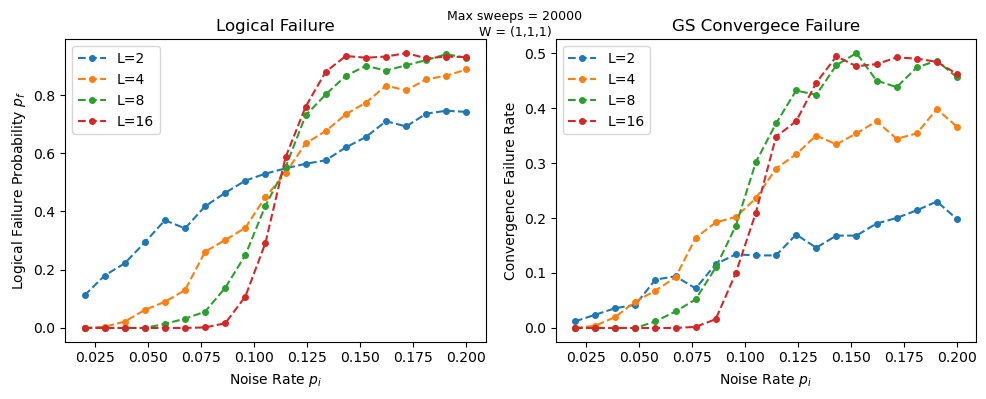

In [195]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
for L in L_arr:
    ax1.plot(p_arr, flogical_arr[L], linestyle='--', marker = 'o', markersize=4, label = f"L={L}")
    ax2.plot(p_arr, fconv_arr[L], linestyle='--', marker = 'o', markersize=4, label = f"L={L}")
    
ax1.set_title("Logical Failure")
ax1.set_xlabel("Noise Rate $p_i$")
ax1.set_ylabel("Logical Failure Probability $p_f$")

ax2.set_title("GS Convergece Failure")
ax2.set_xlabel("Noise Rate $p_i$")
ax2.set_ylabel("Convergence Failure Rate")

ax1.legend()
ax2.legend()

fig.text(
    0.52, 0.92,
    "W = (1,1,1)",
    ha='center',
    fontsize=9
)


fig.text(
    0.52, 0.96,
    "Max sweeps = 20000",
    ha='center',
    fontsize=9
)

plt.savefig('LogConvFail20000(trialdata3).png') 

plt.tight_layout() 

plt.show()

#### Data Collection